# IEOR E4004 — Project I: Eliminating Child Care Deserts in NYC
## Problem of Budgeting (P1) & Realistic Expansion (P2)

| Part | Content |
|------|---------|
| 1 | Data Loading & Cleaning |
| 2 | Feature Engineering & Desert Classification |
| 3 | EDA & Visualizations |
| 4 | Problem 1 — Idealistic Budgeting (Gurobi MIP) |
| 5 | Problem 2 — Realistic Expansion with Distance Constraints (Gurobi MIP) |

## Imports

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings, math
import gurobipy as gp
from gurobipy import GRB

warnings.filterwarnings('ignore')
np.random.seed(42)

PALETTE = {'desert':'#d62728','ok':'#2ca02c','high':'#ff7f0e','normal':'#1f77b4'}
BOR_COLORS = {
    'Manhattan':'#3498db','Bronx':'#e74c3c','Brooklyn':'#2ecc71',
    'Queens':'#e67e22','Staten Island':'#9b59b6','Unknown':'#95a5a6',
}

def get_borough(z):
    z = int(z)
    if   10001 <= z <= 10282: return 'Manhattan'
    elif 10451 <= z <= 10475: return 'Bronx'
    elif 11200 <= z <= 11257: return 'Brooklyn'
    elif z in {11004,11005,11101,11102,11103,11104,11105,11106,11109}          or 11354 <= z <= 11697: return 'Queens'
    elif 10301 <= z <= 10314: return 'Staten Island'
    return 'Unknown'

def haversine_miles(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles."""
    R = 3958.8
    lat1,lon1,lat2,lon2 = map(math.radians,[lat1,lon1,lat2,lon2])
    a = (math.sin((lat2-lat1)/2)**2
         + math.cos(lat1)*math.cos(lat2)*math.sin((lon2-lon1)/2)**2)
    return 2*R*math.asin(math.sqrt(a))

# c_slots: piece-1 cost per slot — step function decreasing in n_f
def c_slots(n):
    if   n <= 20:  return 1200.0
    elif n <= 50:  return 600.0
    elif n <= 100: return 400.0
    elif n <= 200: return 300.0
    else:          return 20000.0/n + 200.0

# piece-2 cost per slot: (20000 + 200*nf)/nf
def c_slots_p2(n):
    return (20000.0 + 200.0*n) / n

print("Setup complete.")

Setup complete.


---
## Part 1 — Data Loading & Cleaning

### 1.1  Load raw files

In [3]:
fac_raw = pd.read_csv('child_care_regulated_nyc.csv')
pop_raw = pd.read_csv('population_nyc.csv')
inc_raw = pd.read_csv('avg_individual_income_nyc.csv')
emp_raw = pd.read_csv('employment_rate_nyc.csv')
loc_raw = pd.read_csv('potential_locations_nyc.csv')

for df in [fac_raw,pop_raw,inc_raw,emp_raw,loc_raw]:
    df.drop(columns=[c for c in df.columns if 'Unnamed' in c], inplace=True)

summary = pd.DataFrame({
    'Dataset':  ['Facilities','Population','Income','Employment','Locations'],
    'Rows':     [len(fac_raw),len(pop_raw),len(inc_raw),len(emp_raw),len(loc_raw)],
    'Columns':  [fac_raw.shape[1],pop_raw.shape[1],inc_raw.shape[1],
                 emp_raw.shape[1],loc_raw.shape[1]],
    'Nulls':    [df.isnull().sum().sum()
                 for df in [fac_raw,pop_raw,inc_raw,emp_raw,loc_raw]],
})
display(summary)

,Dataset,Rows,Columns,Nulls
0,Facilities,7740,15,353
1,Population,211,20,0
2,Income,179,2,0
3,Employment,179,2,0
4,Locations,31100,3,0


### 1.2  Data quality audit

In [4]:
z_inc = set(inc_raw['zipcode'])
z_pop = set(pop_raw['zipcode'])

pop_raw['children_0_12'] = pop_raw['-5'] + pop_raw['6-12']
pop_with_children = set(pop_raw[pop_raw['children_0_12'] > 0]['zipcode'])

# ZIPs with children but missing from income/employment
impute_needed = sorted(pop_with_children - z_inc)
print(f"ZIPs with children but no income/employment data: {impute_needed}")
for z in impute_needed:
    row = pop_raw[pop_raw['zipcode']==z].iloc[0]
    print(f"  ZIP {z} ({get_borough(z)}): "
          f"pop_0_5={row['-5']}, pop_6_12={row['6-12']}")

n_inactive  = (~fac_raw['facility_status'].isin(['License','Registration'])).sum()
n_zero_cap  = (fac_raw['total_capacity']==0).sum()
n_null_ll   = fac_raw['latitude'].isna().sum()
print(f"\nFacility issues:")
print(f"  Inactive / revoked status : {n_inactive}  -> DROP")
print(f"  Zero total_capacity       : {n_zero_cap}  -> DROP")
print(f"  Missing lat/lon           : {n_null_ll}  -> impute from ZIP mean")

ZIPs with children but no income/employment data: [11249, 11430]
  ZIP 11249 (Brooklyn): pop_0_5=4774, pop_6_12=4836
  ZIP 11430 (Queens): pop_0_5=0, pop_6_12=37

Facility issues:
  Inactive / revoked status : 27  -> DROP
  Zero total_capacity       : 1  -> DROP
  Missing lat/lon           : 169  -> impute from ZIP mean


### 1.3  Clean facilities

In [5]:
fac = fac_raw.copy()

# (a) Active only
fac = fac[fac['facility_status'].isin(['License','Registration'])].copy()

# (b) Non-zero capacity
fac = fac[fac['total_capacity'] > 0].copy()

# (c) Age-0-5 capacity:
#     GFDC and FDC facilities store 0-5 slots in children_capacity.
#     Centre-based facilities (SACC) use infant/toddler/preschool columns.
#     Using the union gives the correct 0-5 total (~69,690 slots).
fac['cap_0_5'] = (fac['children_capacity']
                  + fac['infant_capacity']
                  + fac['toddler_capacity']
                  + fac['preschool_capacity'])

# (d) Borough label
fac['borough'] = fac['zipcode'].apply(get_borough)

# (e) Impute missing lat/lon from mean of other facilities in same ZIP
zip_ll = (fac.dropna(subset=['latitude','longitude'])
          .groupby('zipcode')[['latitude','longitude']].mean())
mask = fac['latitude'].isna()
fac.loc[mask,'latitude']  = fac.loc[mask,'zipcode'].map(zip_ll['latitude'])
fac.loc[mask,'longitude'] = fac.loc[mask,'zipcode'].map(zip_ll['longitude'])

fac = fac.reset_index(drop=True)
print(f"Facilities: {len(fac_raw):,}  ->  {len(fac):,} active, non-zero-cap rows")
print(f"  Remaining lat/lon nulls: {fac['latitude'].isna().sum()}")
display(fac[['facility_id','zipcode','borough','total_capacity',
             'cap_0_5','latitude','longitude']].head())

Facilities: 7,740  ->  7,712 active, non-zero-cap rows
  Remaining lat/lon nulls: 0


,facility_id,zipcode,borough,total_capacity,cap_0_5,latitude,longitude
0,51349,10474,Bronx,6,6,40.818399,-73.888816
1,73544,10017,Manhattan,60,0,40.753216,-73.970794
2,108407,11225,Brooklyn,16,12,40.663235,-73.954284
3,111953,11226,Brooklyn,16,12,40.646785,-73.956955
4,126425,10465,Bronx,12,12,40.841228,-73.823572


### 1.4  Clean population

In [6]:
pop = pop_raw.copy()
pop = pop.rename(columns={'-5':'pop_0_5','6-12':'pop_6_12'})
pop['pop_0_12'] = pop['pop_0_5'] + pop['pop_6_12']
pop['borough']  = pop['zipcode'].apply(get_borough)
pop = pop[['zipcode','borough','pop_0_5','pop_6_12','pop_0_12']].copy()
print(f"Population: {len(pop)} ZIP codes")
display(pop.head())

Population: 211 ZIP codes


,zipcode,borough,pop_0_5,pop_6_12,pop_0_12
0,10001,Manhattan,744,1255,1999
1,10002,Manhattan,2142,4645,6787
2,10003,Manhattan,1440,1510,2950
3,10004,Manhattan,433,262,695
4,10005,Manhattan,484,318,802


### 1.5  Clean income & employment — impute 2 missing ZIPs

In [7]:
inc = inc_raw[['zipcode','average income']].copy()
emp = emp_raw[['zipcode','employment rate']].copy()

# Borough medians for imputation
base = inc.merge(emp, on='zipcode').copy()
base['borough'] = base['zipcode'].apply(get_borough)
bor_inc = base.groupby('borough')['average income'].median()
bor_emp = base.groupby('borough')['employment rate'].median()

impute_needed = sorted(set(pop[pop['pop_0_12']>0]['zipcode']) - set(inc['zipcode']))
rows_inc, rows_emp = [], []
for z in impute_needed:
    b = get_borough(z)
    rows_inc.append({'zipcode':z, 'average income':  round(bor_inc[b],2)})
    rows_emp.append({'zipcode':z, 'employment rate': round(bor_emp[b],6)})
    print(f"  ZIP {z} ({b}): income=${bor_inc[b]:,.0f}, "
          f"emp_rate={bor_emp[b]:.4f}  [imputed]")

inc = pd.concat([inc, pd.DataFrame(rows_inc)], ignore_index=True)
emp = pd.concat([emp, pd.DataFrame(rows_emp)], ignore_index=True)
print(f"Income: {len(inc_raw)} -> {len(inc)} rows")
print(f"Employment: {len(emp_raw)} -> {len(emp)} rows")

  ZIP 11249 (Brooklyn): income=$55,444, emp_rate=0.4559  [imputed]
  ZIP 11430 (Queens): income=$59,109, emp_rate=0.4869  [imputed]
Income: 179 -> 181 rows
Employment: 179 -> 181 rows


### 1.6  Clean potential locations

In [8]:
# Filter to ZIPs that appear in income/employment (our working set)
WORKING_ZIPS = set(inc['zipcode']) & set(pop[pop['pop_0_12']>0]['zipcode'])
print(f"Working ZIP count: {len(WORKING_ZIPS)}")

loc = loc_raw.copy()
loc = loc[loc['zipcode'].isin(WORKING_ZIPS)].reset_index(drop=True)
loc['borough'] = loc['zipcode'].apply(get_borough)
print(f"Potential locations: {len(loc_raw):,} -> {len(loc):,} "
      f"(filtered to {loc['zipcode'].nunique()} working ZIPs)")
print(f"Locations per ZIP: {loc.groupby('zipcode').size().describe()[['min','max','mean']].to_dict()}")

Working ZIP count: 180
Potential locations: 31,100 -> 18,000 (filtered to 180 working ZIPs)
Locations per ZIP: {'min': 100.0, 'max': 100.0, 'mean': 100.0}


---
## Part 2 — Feature Engineering & Desert Classification

### 2.1  Build master ZIP-level DataFrame

In [9]:
master = (pop[pop['zipcode'].isin(WORKING_ZIPS)]
          .merge(inc, on='zipcode')
          .merge(emp, on='zipcode'))

# Aggregate facility capacity per ZIP
cc_zip = (fac[fac['zipcode'].isin(WORKING_ZIPS)]
          .groupby('zipcode')
          .agg(n_facilities =('facility_id','count'),
               total_slots  =('total_capacity','sum'),
               slots_0_5    =('cap_0_5','sum'))
          .reset_index())

master = master.merge(cc_zip, on='zipcode', how='left')
master['n_facilities'] = master['n_facilities'].fillna(0).astype(int)
master['total_slots']  = master['total_slots'].fillna(0).astype(int)
master['slots_0_5']    = master['slots_0_5'].fillna(0).astype(int)

print(f"Master DataFrame: {master.shape}")
display(master.head())

Master DataFrame: (180, 10)


,zipcode,borough,pop_0_5,pop_6_12,pop_0_12,average income,employment rate,n_facilities,total_slots,slots_0_5
0,10001,Manhattan,744,1255,1999,102878.033603,0.595097,9,609,24
1,10002,Manhattan,2142,4645,6787,59604.041165,0.520662,56,4724,216
2,10003,Manhattan,1440,1510,2950,114273.049645,0.497244,7,1995,0
3,10004,Manhattan,433,262,695,132004.310345,0.506661,2,263,0
4,10005,Manhattan,484,318,802,121437.713311,0.665833,1,39,0


### 2.2  Desert classification & deficit calculation

In [10]:
# High-demand: emp_rate >= 60% OR avg_income <= $60,000
master['high_demand'] = ((master['employment rate'] >= 0.60) |
                          (master['average income']  <= 60_000))

# Desert threshold per ZIP
master['desert_threshold'] = np.where(
    master['high_demand'],
    0.5  * master['pop_0_12'],
    (1/3)* master['pop_0_12']
)

# Desert flag: slots <= threshold (strictly need slots > threshold to exit)
master['is_desert'] = master['total_slots'] <= master['desert_threshold']

# Required slots: must be STRICTLY greater than threshold
master['req_total'] = (np.floor(master['desert_threshold']) + 1).astype(int)

# Deficit to exit desert
master['total_deficit'] = np.where(
    master['is_desert'],
    (master['req_total'] - master['total_slots']).clip(lower=0),
    0
).astype(int)

# Age 0-5 NYC policy: available 0-5 slots >= (2/3) * pop_0_5
master['req_0_5']    = np.ceil((2/3) * master['pop_0_5']).astype(int)
master['deficit_0_5']= (master['req_0_5'] - master['slots_0_5']).clip(lower=0).astype(int)
master['fails_u5']   = master['slots_0_5'] < master['req_0_5']

# Coverage ratio
master['coverage_ratio'] = (master['total_slots'] /
                             master['pop_0_12'].replace(0, np.nan))

print(f"Working ZIPs         : {len(master)}")
print(f"High-demand ZIPs     : {master['high_demand'].sum()}  "
      f"({master['high_demand'].mean():.1%})")
print(f"Child care deserts   : {master['is_desert'].sum()}  "
      f"({master['is_desert'].mean():.1%})")
print(f"  High-demand deserts: {(master['high_demand']&master['is_desert']).sum()}")
print(f"  Normal deserts     : {(~master['high_demand']&master['is_desert']).sum()}")
print(f"Total slot deficit   : {master['total_deficit'].sum():,}")
print(f"Total 0-5 deficit    : {master['deficit_0_5'].sum():,}")
print(f"ZIPs failing 0-5 rule: {master['fails_u5'].sum()}")

Working ZIPs         : 180
High-demand ZIPs     : 97  (53.9%)
Child care deserts   : 162  (90.0%)
  High-demand deserts: 91
  Normal deserts     : 71
Total slot deficit   : 238,068
Total 0-5 deficit    : 277,184
ZIPs failing 0-5 rule: 179


In [11]:
print("=" * 55)
print("  KEY SUMMARY STATISTICS")
print("=" * 55)

stats = {
    'Total zipcodes (working)':        len(master),
    'High-demand zipcodes':            int(master['high_demand'].sum()),
    'Normal-demand zipcodes':          int((~master['high_demand']).sum()),
    'Child care deserts':              int(master['is_desert'].sum()),
    '  - High-demand deserts':         int((master['high_demand'] & master['is_desert']).sum()),
    '  - Normal-demand deserts':       int((~master['high_demand'] & master['is_desert']).sum()),
    'Total active facilities':         len(fac[fac['zipcode'].isin(WORKING_ZIPS)]),
    'Total existing slots (all)':      int(master['total_slots'].sum()),
    'Total existing slots (0-5)':      int(master['slots_0_5'].sum()),
    'Total pop 0-12':                  int(master['pop_0_12'].sum()),
    'Total pop 0-5':                   int(master['pop_0_5'].sum()),
    'Total slot deficit (deserts)':    int(master['total_deficit'].sum()),
    'Total under-5 deficit':           int(master['deficit_0_5'].sum()),
    'Zipcodes failing under-5 rule':   int(master['fails_u5'].sum()),
}

for k, v in stats.items():
    print(f"  {k:<40} {v:>10,}")

print("=" * 55)

  KEY SUMMARY STATISTICS
  Total zipcodes (working)                        180
  High-demand zipcodes                             97
  Normal-demand zipcodes                           83
  Child care deserts                              162
    - High-demand deserts                          91
    - Normal-demand deserts                        71
  Total active facilities                       7,708
  Total existing slots (all)                  317,295
  Total existing slots (0-5)                   69,690
  Total pop 0-12                            1,239,727
  Total pop 0-5                               520,214
  Total slot deficit (deserts)                238,068
  Total under-5 deficit                       277,184
  Zipcodes failing under-5 rule                   179


Monte Carlo Results (N=1,000 simulations)
Noise: emp_rate ±0.03, income ±5%, population ±3%



,Metric,Observed,MC Mean,MC P5,MC P95
0,Total slot deficit,238068,"239,698","234,351","244,820"
1,Under-5 deficit,277184,"277,215","275,739","278,672"
2,# Desert ZIPs,162,161.4,159,163
3,# High-demand ZIPs,97,97.0,93,101


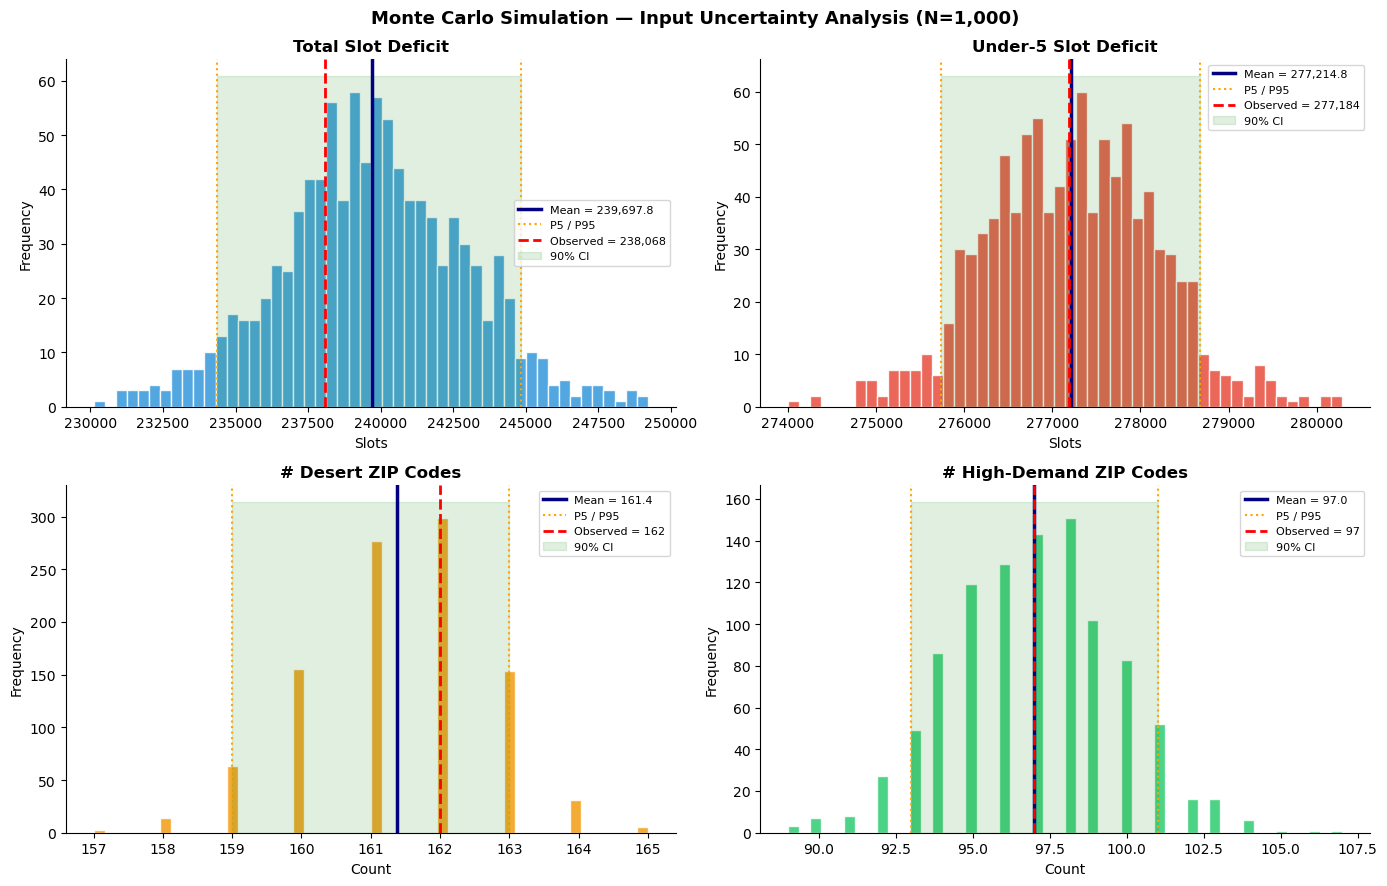


90% CI — Total slot deficit  : [234,351  –  244,820]
90% CI — Under-5 deficit     : [275,739  –  278,672]
90% CI — # Desert ZIPs       : [159  –  163]


In [12]:
# ─────────────────────────────────────────────────────────────
# MONTE CARLO SIMULATION
# Purpose: quantify how sensitive the desert classification and
# slot deficit are to uncertainty in the three key inputs:
#   - employment rate  (σ = 0.03, i.e. ±3 percentage points)
#   - average income   (σ = 5%  of observed value)
#   - child population (σ = 3%  of observed value)
# We run N=1,000 simulations. In each run we:
#   1. Perturb inputs with Gaussian noise
#   2. Recompute high_demand flag and desert threshold
#   3. Recompute total slot deficit across all ZIPs
# This gives a distribution over possible deficit outcomes.
# ─────────────────────────────────────────────────────────────

N_SIM = 1_000

emp_obs  = master['employment rate'].values.copy()
inc_obs  = master['average income'].values.copy()
pop_obs  = master['pop_0_12'].values.copy()
p05_obs  = master['pop_0_5'].values.copy()
exist_obs= master['total_slots'].values.copy()

mc_total_deficit = np.zeros(N_SIM)
mc_u5_deficit    = np.zeros(N_SIM)
mc_n_deserts     = np.zeros(N_SIM, dtype=int)
mc_n_hd          = np.zeros(N_SIM, dtype=int)

for i in range(N_SIM):
    # Perturb inputs (clip to realistic bounds)
    emp_s = np.clip(emp_obs + np.random.normal(0, 0.03, len(master)), 0.20, 0.98)
    inc_s = np.clip(inc_obs * (1 + np.random.normal(0, 0.05, len(master))), 10_000, None)
    pop_s = np.clip(pop_obs * (1 + np.random.normal(0, 0.03, len(master))), 0, None)
    p05_s = pop_s * (p05_obs / np.where(pop_obs > 0, pop_obs, 1))  # scale proportionally

    # Recompute classification
    hd_s   = (emp_s >= 0.60) | (inc_s <= 60_000)
    thr_s  = np.where(hd_s, 0.5 * pop_s, (1/3) * pop_s)
    req_s  = np.floor(thr_s) + 1
    req05_s= np.ceil((2/3) * p05_s)

    deficit_s    = (req_s   - exist_obs).clip(min=0)
    u5_deficit_s = (req05_s - master['slots_0_5'].values).clip(min=0)

    mc_total_deficit[i] = deficit_s.sum()
    mc_u5_deficit[i]    = u5_deficit_s.sum()
    mc_n_deserts[i]     = (deficit_s > 0).sum()
    mc_n_hd[i]          = hd_s.sum()

# ── Summary statistics ────────────────────────────────────────
mc_results = pd.DataFrame({
    'Metric':   ['Total slot deficit','Under-5 deficit',
                 '# Desert ZIPs','# High-demand ZIPs'],
    'Observed': [int(master['total_deficit'].sum()),
                 int(master['deficit_0_5'].sum()),
                 int(master['is_desert'].sum()),
                 int(master['high_demand'].sum())],
    'MC Mean':  [f"{mc_total_deficit.mean():,.0f}",
                 f"{mc_u5_deficit.mean():,.0f}",
                 f"{mc_n_deserts.mean():.1f}",
                 f"{mc_n_hd.mean():.1f}"],
    'MC P5':    [f"{np.percentile(mc_total_deficit,5):,.0f}",
                 f"{np.percentile(mc_u5_deficit,5):,.0f}",
                 f"{np.percentile(mc_n_deserts,5):.0f}",
                 f"{np.percentile(mc_n_hd,5):.0f}"],
    'MC P95':   [f"{np.percentile(mc_total_deficit,95):,.0f}",
                 f"{np.percentile(mc_u5_deficit,95):,.0f}",
                 f"{np.percentile(mc_n_deserts,95):.0f}",
                 f"{np.percentile(mc_n_hd,95):.0f}"],
})
print("Monte Carlo Results (N=1,000 simulations)")
print("Noise: emp_rate ±0.03, income ±5%, population ±3%\n")
display(mc_results)

# ── Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Monte Carlo Simulation — Input Uncertainty Analysis (N=1,000)',
             fontsize=13, fontweight='bold')

for ax, vals, base, lbl, unit, c in [
    (axes[0,0], mc_total_deficit, master['total_deficit'].sum(),
     'Total Slot Deficit', 'Slots', '#3498db'),
    (axes[0,1], mc_u5_deficit, master['deficit_0_5'].sum(),
     'Under-5 Slot Deficit', 'Slots', '#e74c3c'),
    (axes[1,0], mc_n_deserts, master['is_desert'].sum(),
     '# Desert ZIP Codes', 'Count', '#f39c12'),
    (axes[1,1], mc_n_hd, master['high_demand'].sum(),
     '# High-Demand ZIP Codes', 'Count', '#2ecc71'),
]:
    ax.hist(vals, bins=50, color=c, edgecolor='white', alpha=0.85)
    mn   = vals.mean()
    p5   = np.percentile(vals, 5)
    p95  = np.percentile(vals, 95)
    ax.axvline(mn,   color='navy',   lw=2.5, label=f'Mean = {mn:,.1f}')
    ax.axvline(p5,   color='orange', lw=1.5, ls=':', label='P5 / P95')
    ax.axvline(p95,  color='orange', lw=1.5, ls=':')
    ax.axvline(base, color='red',    lw=2,   ls='--', label=f'Observed = {base:,.0f}')
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 1],
                     p5, p95, alpha=0.12, color='green', label='90% CI')
    ax.set_ylim(bottom=0)
    ax.set_xlabel(unit)
    ax.set_ylabel('Frequency')
    ax.set_title(lbl, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('mc_simulation.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n90% CI — Total slot deficit  : "
      f"[{np.percentile(mc_total_deficit,5):,.0f}  –  {np.percentile(mc_total_deficit,95):,.0f}]")
print(f"90% CI — Under-5 deficit     : "
      f"[{np.percentile(mc_u5_deficit,5):,.0f}  –  {np.percentile(mc_u5_deficit,95):,.0f}]")
print(f"90% CI — # Desert ZIPs       : "
      f"[{np.percentile(mc_n_deserts,5):.0f}  –  {np.percentile(mc_n_deserts,95):.0f}]")

---
## Part 3 — EDA & Visualizations

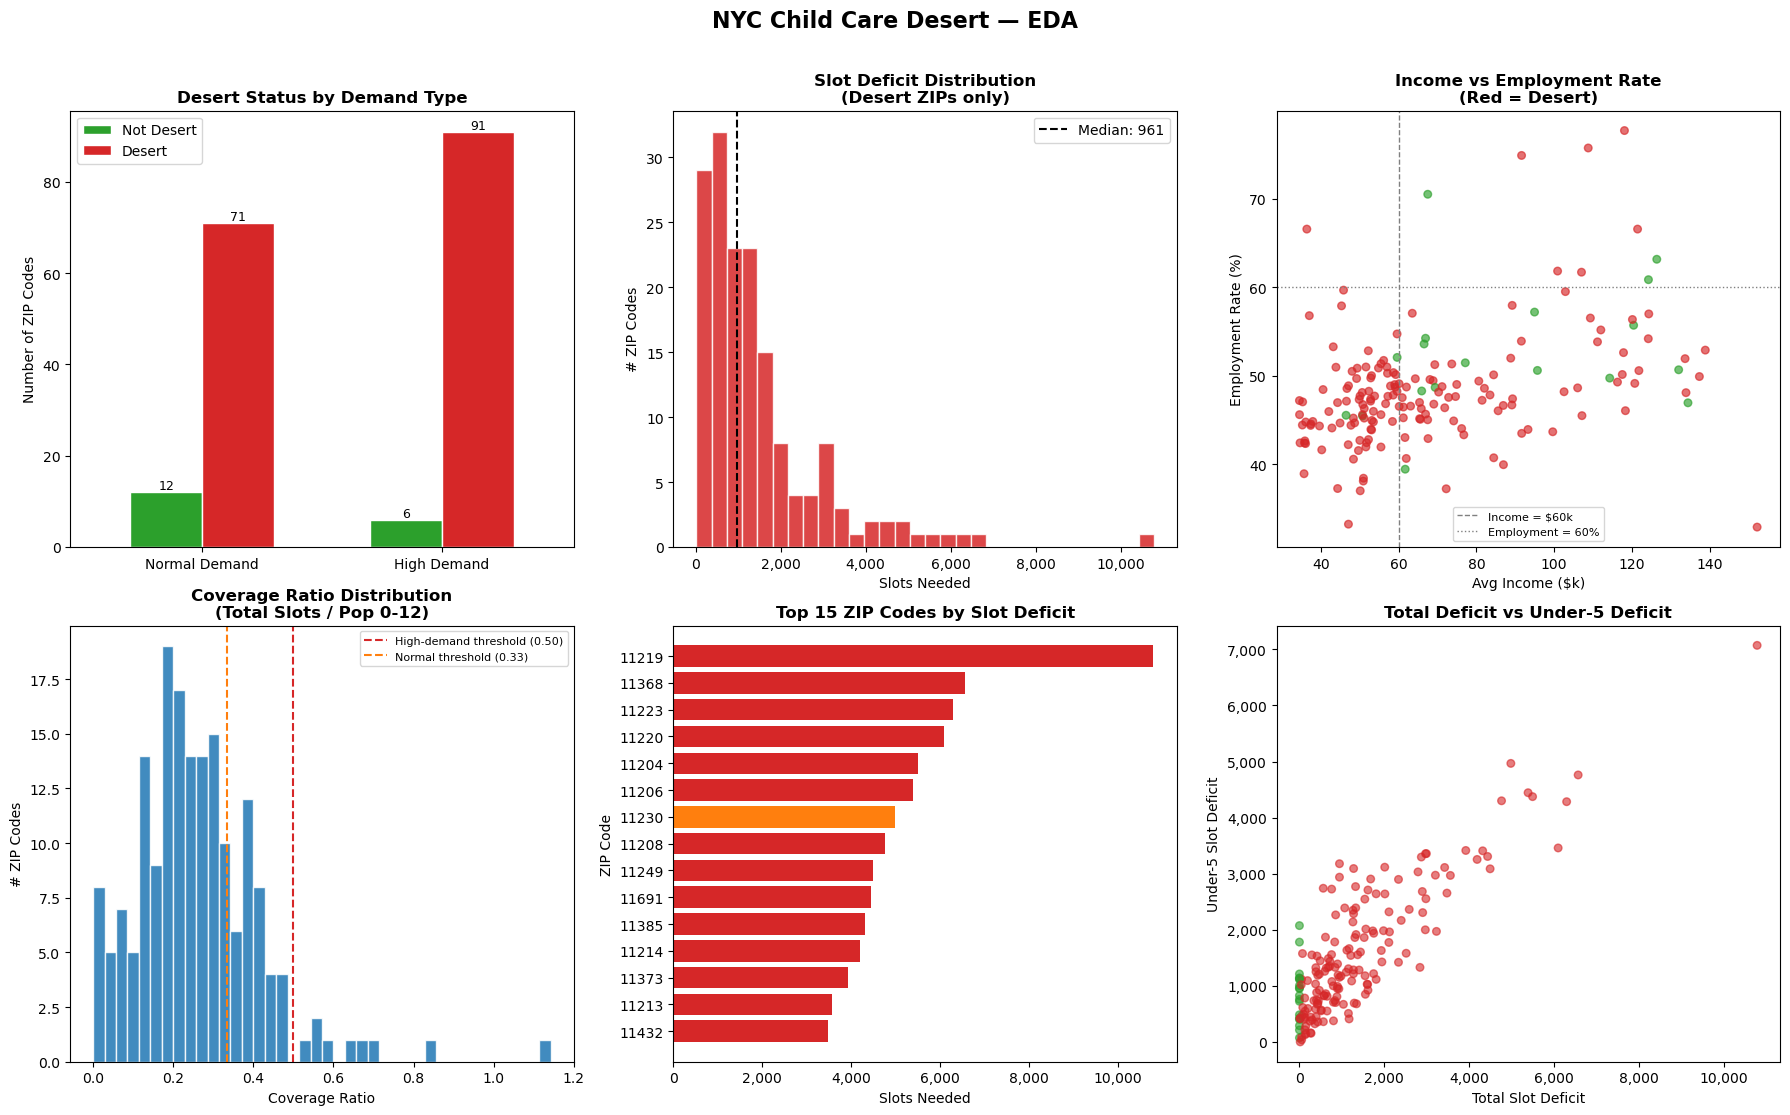

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('NYC Child Care Desert — EDA', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Desert status by demand type
ax = axes[0,0]
counts = (master.groupby(['high_demand','is_desert'])
          .size().unstack(fill_value=0))
counts.index = ['Normal Demand','High Demand']
counts.columns = ['Not Desert','Desert']
counts.plot(kind='bar', ax=ax,
            color=[PALETTE['ok'],PALETTE['desert']],
            edgecolor='white', width=0.6)
ax.set_title('Desert Status by Demand Type', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Number of ZIP Codes')
ax.set_xticklabels(counts.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fontsize=9)
ax.legend()

# Plot 2: Slot deficit distribution (desert ZIPs only)
ax = axes[0,1]
d = master[master['total_deficit']>0]['total_deficit']
ax.hist(d, bins=30, color=PALETTE['desert'], edgecolor='white', alpha=0.85)
ax.axvline(d.median(), color='black', ls='--', lw=1.5,
           label=f'Median: {d.median():,.0f}')
ax.set_title('Slot Deficit Distribution\n(Desert ZIPs only)', fontweight='bold')
ax.set_xlabel('Slots Needed'); ax.set_ylabel('# ZIP Codes')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()

# Plot 3: Income vs Employment Rate scatter
ax = axes[0,2]
colors = master['is_desert'].map({True:PALETTE['desert'],False:PALETTE['ok']})
ax.scatter(master['average income']/1000, master['employment rate']*100,
           c=colors, alpha=0.65, s=30)
ax.axvline(60, color='gray', ls='--', lw=1, label='Income = $60k')
ax.axhline(60, color='gray', ls=':',  lw=1, label='Employment = 60%')
ax.set_title('Income vs Employment Rate\n(Red = Desert)', fontweight='bold')
ax.set_xlabel('Avg Income ($k)'); ax.set_ylabel('Employment Rate (%)')
ax.legend(fontsize=8)

# Plot 4: Coverage ratio distribution
ax = axes[1,0]
ax.hist(master['coverage_ratio'].dropna(), bins=40,
        color=PALETTE['normal'], edgecolor='white', alpha=0.85)
ax.axvline(0.5, color=PALETTE['desert'], ls='--', lw=1.5,
           label='High-demand threshold (0.50)')
ax.axvline(1/3, color=PALETTE['high'], ls='--', lw=1.5,
           label='Normal threshold (0.33)')
ax.set_title('Coverage Ratio Distribution\n(Total Slots / Pop 0-12)', fontweight='bold')
ax.set_xlabel('Coverage Ratio'); ax.set_ylabel('# ZIP Codes')
ax.legend(fontsize=8)

# Plot 5: Top 15 worst deserts
ax = axes[1,1]
top15 = master.nlargest(15,'total_deficit')[
    ['zipcode','total_deficit','high_demand']].copy()
top15['zipcode'] = top15['zipcode'].astype(str)
bar_c = top15['high_demand'].map({True:PALETTE['desert'],
                                   False:PALETTE['high']}).values
ax.barh(top15['zipcode'][::-1], top15['total_deficit'][::-1],
        color=bar_c[::-1])
ax.set_title('Top 15 ZIP Codes by Slot Deficit', fontweight='bold')
ax.set_xlabel('Slots Needed'); ax.set_ylabel('ZIP Code')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Plot 6: Total deficit vs under-5 deficit
ax = axes[1,2]
ax.scatter(master['total_deficit'], master['deficit_0_5'],
           c=master['is_desert'].map({True:PALETTE['desert'],
                                       False:PALETTE['ok']}),
           alpha=0.6, s=30)
ax.set_title('Total Deficit vs Under-5 Deficit', fontweight='bold')
ax.set_xlabel('Total Slot Deficit'); ax.set_ylabel('Under-5 Slot Deficit')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Part 4 — Problem 1: Idealistic Budgeting

### Mathematical Formulation

**Sets:**
- Z = working ZIP codes; F(z) = active facilities in ZIP z; S = {small, medium, large}

**Per-ZIP parameters:**
- `N_z = Σ_{f∈F(z)} n_f` — sum of current slots
- `UB1_z = N_z` — piece-1 headroom (can expand up to n_f per facility, summed)
- `UB_z = Σ_f min(1.2·n_f, 500)` — total expansion cap
- `avg_cs1_z` = capacity-weighted average of `c_slots(n_f)` (piece-1 rate)
- `avg_cs2_z` = capacity-weighted average of `(20000+200·n_f)/n_f` (piece-2 rate)

**Decision variables:**
- `X1[z] ≥ 0` — piece-1 expansion slots in ZIP z (x_f < n_f regime, per facility)
- `X2[z] ≥ 0` — piece-2 expansion slots in ZIP z (x_f ≥ n_f regime)
- `U[z] ≥ 0` — under-5 slots added via expansion in ZIP z
- `y[z,s] ∈ ℤ≥0` — number of size-s new facilities in ZIP z

**Objective — minimize total funding:**
```
min  Σ_z [ avg_cs1_z·X1[z] + avg_cs2_z·X2[z] + 100·U[z]
         + Σ_s (C_s + 100·cap05_s)·y[z,s] ]
```

**Constraints:**
1. `X1[z] ≤ UB1_z`  (piece-1 range)
2. `X1[z] + X2[z] ≤ UB_z`  (total expansion cap)
3. `U[z] ≤ X1[z] + X2[z]`  (can't add more 0-5 than total expanded)
4. `existing_z + X1[z] + X2[z] + Σ_s cap_s·y[z,s] ≥ req_total_z`
5. `existing_0_5_z + U[z] + Σ_s cap05_s·y[z,s] ≥ req_0_5_z`

### 4.1  Compute ZIP-level parameters

In [14]:
SIZES = {
    'small':  {'cap':100, 'cap05': 50, 'cost': 65_000},
    'medium': {'cap':200, 'cap05':100, 'cost': 95_000},
    'large':  {'cap':400, 'cap05':200, 'cost':115_000},
}
EQUIP = 100   # $ per new/expanded 0-5 slot
sizes = list(SIZES.keys())

# Facilities restricted to working ZIPs, non-zero capacity
fac_w = fac[fac['zipcode'].isin(WORKING_ZIPS)].copy()

# Per-ZIP expansion parameters
def zip_expansion_params(group):
    nf    = group['total_capacity'].values.astype(float)
    N_z   = nf.sum()
    if N_z == 0:
        return pd.Series({'N_z':0,'UB1':0,'UB_total':0,
                          'avg_cs1':0,'avg_cs2':0})
    cs1   = np.array([c_slots(n)   for n in nf])
    cs2   = np.array([c_slots_p2(n) for n in nf])
    ub_f  = np.minimum(1.2*nf, 500)
    return pd.Series({
        'N_z':      N_z,
        'UB1':      N_z,                          # piece-1 headroom = sum nf
        'UB_total': ub_f.sum(),                   # total expansion cap
        'avg_cs1':  np.dot(cs1, nf) / N_z,        # capacity-weighted piece-1 rate
        'avg_cs2':  np.dot(cs2, nf) / N_z,        # capacity-weighted piece-2 rate
    })

zip_params = (fac_w.groupby('zipcode')
              .apply(zip_expansion_params)
              .reset_index())

# Merge with master
df1 = master.merge(zip_params, on='zipcode', how='left')
for c in ['N_z','UB1','UB_total','avg_cs1','avg_cs2']:
    df1[c] = df1[c].fillna(0)

print("ZIP-level expansion parameters computed.")
print(df1[['zipcode','total_slots','slots_0_5','N_z','UB_total',
           'avg_cs1','avg_cs2']].head(8).to_string(index=False))

ZIP-level expansion parameters computed.
 zipcode  total_slots  slots_0_5    N_z  UB_total    avg_cs1    avg_cs2
   10001          609         24  609.0     730.8 423.645320 495.566502
   10002         4724        216 4724.0    5668.8 359.398815 437.087214
   10003         1995          0 1995.0    2191.2 260.952381 270.175439
   10004          263          0  263.0     315.6 325.475285 352.091255
   10005           39          0   39.0      46.8 600.000000 712.820513
   10006          156         14  156.0     187.2 300.000000 328.205128
   10007          284          0  284.0     340.8 384.507042 411.267606
   10009         1784        124 1784.0    2140.8 377.186099 457.847534


### 4.2  Build and solve Gurobi model (Problem 1)

In [15]:
# -------------------------------
# 4.2 Build and solve Gurobi model (FACILITY-LEVEL VERSION)
# -------------------------------

zips  = df1['zipcode'].tolist()
df1_i = df1.set_index('zipcode')

# -------------------------------
# NEW: Facility-level setup
# -------------------------------
facilities = fac_w.index.tolist()
fac_dict   = fac_w.copy()

# Map facilities → ZIP
fac_by_zip = fac_w.groupby('zipcode').apply(lambda x: x.index.tolist()).to_dict()

# -------------------------------
# Model
# -------------------------------
m1 = gp.Model('P1_Budgeting_FacilityLevel')
m1.setParam('OutputFlag', 1)
m1.setParam('MIPGap', 1e-4)
m1.setParam('TimeLimit', 300)

# -------------------------------
# Decision variables
# -------------------------------
x1 = m1.addVars(facilities, lb=0.0, name='x1')   # piece-1 expansion
x2 = m1.addVars(facilities, lb=0.0, name='x2')   # piece-2 expansion
u  = m1.addVars(facilities, lb=0.0, name='u')    # under-5 expansion

y  = m1.addVars(zips, sizes, lb=0, vtype=GRB.INTEGER, name='y')

# -------------------------------
# Facility-level constraints
# -------------------------------
for f in facilities:
    nf = fac_dict.loc[f, 'total_capacity']
    max_exp = min(1.2 * nf, 500)

    m1.addConstr(x1[f] <= nf, name=f'ub1_{f}')
    m1.addConstr(x1[f] + x2[f] <= max_exp, name=f'ubt_{f}')
    m1.addConstr(u[f] <= x1[f] + x2[f], name=f'u5b_{f}')

# -------------------------------
# ZIP-level demand constraints
# -------------------------------
for z in zips:
    r = df1_i.loc[z]
    facs_z = fac_by_zip.get(z, [])

    exp_slots = gp.quicksum(x1[f] + x2[f] for f in facs_z)
    exp_u5    = gp.quicksum(u[f] for f in facs_z)

    new_slots = gp.quicksum(SIZES[s]['cap'] * y[z,s] for s in sizes)
    new_u5    = gp.quicksum(SIZES[s]['cap05'] * y[z,s] for s in sizes)

    # Desert elimination
    m1.addConstr(
        r['total_slots'] + exp_slots + new_slots >= r['req_total'],
        name=f'desert_{z}'
    )

    # Age 0-5 constraint
    m1.addConstr(
        r['slots_0_5'] + exp_u5 + new_u5 >= r['req_0_5'],
        name=f'u5_{z}'
    )

# -------------------------------
# Objective function
# -------------------------------
exp_cost = gp.quicksum(
    c_slots(fac_dict.loc[f,'total_capacity']) * x1[f] +
    c_slots_p2(fac_dict.loc[f,'total_capacity']) * x2[f] +
    EQUIP * u[f]
    for f in facilities
)

build_cost = gp.quicksum(
    (SIZES[s]['cost'] + EQUIP*SIZES[s]['cap05']) * y[z,s]
    for z in zips for s in sizes
)

m1.setObjective(exp_cost + build_cost, GRB.MINIMIZE)

print(f"Variables  : {m1.NumVars:,}")
print(f"Constraints: {m1.NumConstrs:,}")
print("\nSolving...")

m1.optimize()

print(f"\nStatus: {m1.Status}  ({'OPTIMAL' if m1.Status==2 else 'OTHER'})")
print(f"Total cost: ${m1.ObjVal:,.0f}")

Set parameter Username
Set parameter LicenseID to value 2774010
Academic license - for non-commercial use only - expires 2027-02-02
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter TimeLimit to value 300
Variables  : 0
Constraints: 0

Solving...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 23484 rows, 23664 columns and 70452 nonzeros (Min)
Model fingerprint: 0x35cf2254
Model has 23664 linear objective coefficients
Variable types: 23124 continuous, 540 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+02]
  Objective range  [1e+02, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 1e+04]

Found heuristic solution: objective 1.991250e+08
Presolve removed 23415 rows and 23556 columns
Presolve time: 0.15s
Presolve

### 4.3  Extract and display Problem 1 results

In [16]:
# -------------------------------
# 4.3 Extract and display results (FACILITY-LEVEL)
# -------------------------------

# Cost breakdown
p1_exp_cost = sum(
    c_slots(fac_dict.loc[f,'total_capacity']) * x1[f].X +
    c_slots_p2(fac_dict.loc[f,'total_capacity']) * x2[f].X
    for f in facilities
)

p1_u5_exp_cost = sum(EQUIP * u[f].X for f in facilities)

p1_build_cost = sum(
    SIZES[s]['cost'] * y[z,s].X
    for z in zips for s in sizes
)

p1_equip_cost = sum(
    EQUIP * SIZES[s]['cap05'] * y[z,s].X
    for z in zips for s in sizes
)

print("=" * 55)
print("  PROBLEM 1 — MINIMUM FUNDING (FACILITY LEVEL)")
print("=" * 55)
print(f"  Total minimum funding     : ${m1.ObjVal:>15,.0f}")
print(f"  MIP gap                   : {m1.MIPGap*100:.4f}%")

# -------------------------------
# Expansion summary
# -------------------------------
n_exp = sum(1 for f in facilities if x1[f].X + x2[f].X > 0.01)
tot_exp = sum(x1[f].X + x2[f].X for f in facilities)

print(f"\n  Facilities expanded: {n_exp}")
print(f"  Slots via expansion: {tot_exp:,.0f}")

tot_new = sum(SIZES[s]['cap'] * y[z,s].X for z in zips for s in sizes)
print(f"  Slots via new builds: {tot_new:,.0f}")

# -------------------------------
# Per-ZIP results
# -------------------------------
rows = []
for z in zips:
    r = df1_i.loc[z]
    facs_z = fac_by_zip.get(z, [])

    exp_z = sum(x1[f].X + x2[f].X for f in facs_z)
    u5_z  = sum(u[f].X for f in facs_z)

    new_z = sum(SIZES[s]['cap'] * y[z,s].X for s in sizes)

    rows.append({
        'zipcode': z,
        'borough': r['borough'],
        'existing_slots': r['total_slots'],
        'expanded_slots': round(exp_z,1),
        'new_slots': round(new_z,1),
        'final_slots': round(r['total_slots'] + exp_z + new_z,1),
        'req_total': r['req_total'],
        'existing_0_5': r['slots_0_5'],
        'added_0_5': round(u5_z,1),
        'final_0_5': round(r['slots_0_5'] + u5_z,1),
        'req_0_5': r['req_0_5'],
        'desert_ok': (r['total_slots'] + exp_z + new_z) >= r['req_total'] - 0.5,
        'u5_ok': (r['slots_0_5'] + u5_z) >= r['req_0_5'] - 0.5,
    })

res1 = pd.DataFrame(rows)
res1.to_csv('p1_results_facility_level.csv', index=False)

print(f"\n  Desert eliminated : {res1['desert_ok'].sum()}/{len(res1)} ZIPs")
print(f"  0-5 policy met    : {res1['u5_ok'].sum()}/{len(res1)} ZIPs")
print("  Saved: p1_results_facility_level.csv")

  PROBLEM 1 — MINIMUM FUNDING (FACILITY LEVEL)
  Total minimum funding     : $    134,488,789
  MIP gap                   : 0.0000%

  Facilities expanded: 1072
  Slots via expansion: 191,638
  Slots via new builds: 176,100

  Desert eliminated : 180/180 ZIPs
  0-5 policy met    : 69/180 ZIPs
  Saved: p1_results_facility_level.csv


P1 total slots added      : 367,738
P1 avg cost per slot      : $366


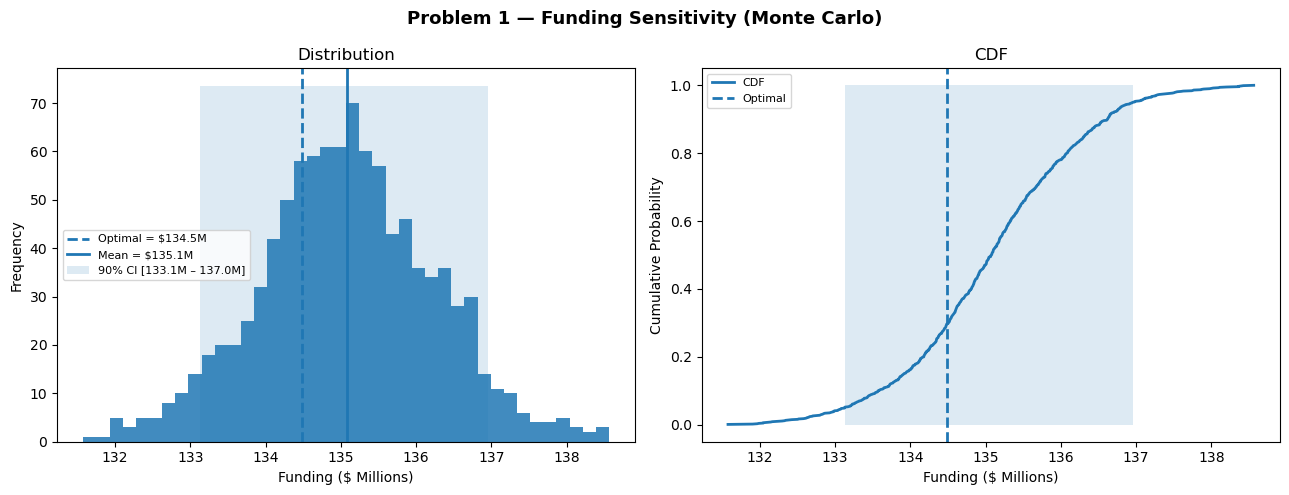


P1 MONTE CARLO RESULTS
Optimal funding        : $134,488,789
Mean funding           : $135,084,836
90% range              : $133,129,521  –  $136,958,252

Interpretation:
Funding requirement is sensitive to demand uncertainty.
Budget planning should consider upper percentile (e.g., 95%) rather than point estimate.


In [18]:
# ── P1 Monte Carlo Funding Uncertainty (FACILITY-LEVEL CONSISTENT) ─────────────

# -------------------------------
# Base deficit (from deterministic model input)
# -------------------------------
observed_deficit = master['total_deficit'].sum()

# -------------------------------
# Slots added in optimal solution
# -------------------------------
expansion_slots = sum(x1[f].X + x2[f].X for f in facilities)

new_build_slots = sum(
    SIZES[s]['cap'] * y[z,s].X
    for z in zips for s in sizes
)

total_slots_added_p1 = expansion_slots + new_build_slots

# -------------------------------
# Average cost per slot (safe)
# -------------------------------
if total_slots_added_p1 > 0:
    p1_avg_cost_per_slot = m1.ObjVal / total_slots_added_p1
else:
    p1_avg_cost_per_slot = 0

print(f"P1 total slots added      : {total_slots_added_p1:,.0f}")
print(f"P1 avg cost per slot      : ${p1_avg_cost_per_slot:,.0f}")

# -------------------------------
# Monte Carlo funding calculation
# -------------------------------
# Ensure mc_total_deficit is numpy array
mc_total_deficit = np.array(mc_total_deficit)

delta_p1 = mc_total_deficit - observed_deficit

mc_p1_funding = m1.ObjVal + delta_p1 * p1_avg_cost_per_slot

# -------------------------------
# Summary stats
# -------------------------------
p1_mean = mc_p1_funding.mean()
p1_l5   = np.percentile(mc_p1_funding, 5)
p1_h95  = np.percentile(mc_p1_funding, 95)

# -------------------------------
# Visualization
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problem 1 — Funding Sensitivity (Monte Carlo)',
             fontsize=13, fontweight='bold')

# ---------- Histogram ----------
ax = axes[0]
ax.hist(mc_p1_funding / 1e6, bins=40, alpha=0.85)

ax.axvline(m1.ObjVal / 1e6, linestyle='--', linewidth=2,
           label=f'Optimal = ${m1.ObjVal/1e6:.1f}M')

ax.axvline(p1_mean / 1e6, linewidth=2,
           label=f'Mean = ${p1_mean/1e6:.1f}M')

ax.fill_betweenx(
    [0, ax.get_ylim()[1]],
    p1_l5 / 1e6,
    p1_h95 / 1e6,
    alpha=0.15,
    label=f'90% CI [{p1_l5/1e6:.1f}M – {p1_h95/1e6:.1f}M]'
)

ax.set_xlabel('Funding ($ Millions)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution')
ax.legend(fontsize=8)

# ---------- CDF ----------
ax = axes[1]
sorted_vals = np.sort(mc_p1_funding / 1e6)
cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

ax.plot(sorted_vals, cdf_vals, linewidth=2, label='CDF')

ax.axvline(m1.ObjVal / 1e6, linestyle='--', linewidth=2,
           label='Optimal')

ax.fill_betweenx(
    [0, 1],
    p1_l5 / 1e6,
    p1_h95 / 1e6,
    alpha=0.15
)

ax.set_xlabel('Funding ($ Millions)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mc_p1_cost.png', dpi=120)
plt.show()

# -------------------------------
# Final output
# -------------------------------
print("\n" + "="*60)
print("P1 MONTE CARLO RESULTS")
print("="*60)

print(f"Optimal funding        : ${m1.ObjVal:,.0f}")
print(f"Mean funding           : ${p1_mean:,.0f}")
print(f"90% range              : ${p1_l5:,.0f}  –  ${p1_h95:,.0f}")

print("\nInterpretation:")
print("Funding requirement is sensitive to demand uncertainty.")
print("Budget planning should consider upper percentile (e.g., 95%) rather than point estimate.")

### 4.4  Problem 1 result visualizations

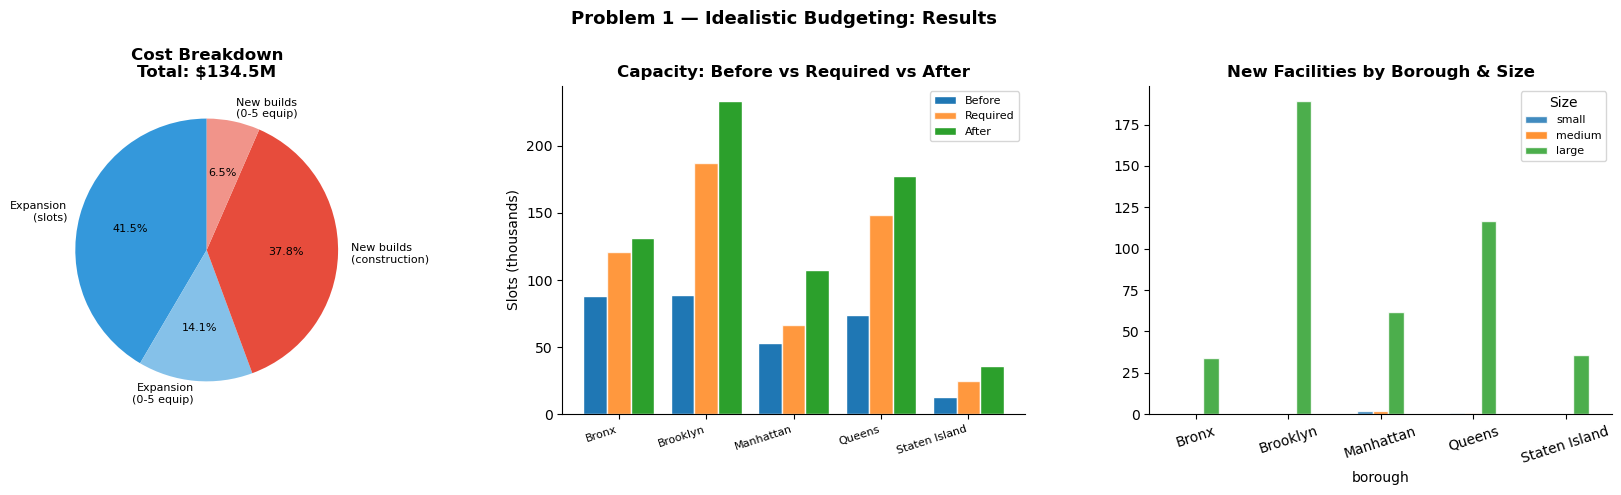

In [20]:
# ── Problem 1 Visualization (FACILITY-LEVEL CONSISTENT) ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Problem 1 — Idealistic Budgeting: Results',
             fontsize=13, fontweight='bold')

# -------------------------------
# 1. Cost breakdown pie
# -------------------------------
ax = axes[0]

labels = [
    'Expansion\n(slots)',
    'Expansion\n(0-5 equip)',
    'New builds\n(construction)',
    'New builds\n(0-5 equip)'
]

vals = [
    p1_exp_cost,
    p1_u5_exp_cost,
    p1_build_cost,
    p1_equip_cost
]

# Handle edge case (all zeros)
if sum(vals) == 0:
    vals = [1, 0, 0, 0]

colors = ['#3498db', '#85c1e9', '#e74c3c', '#f1948a']

ax.pie(
    vals,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':8}
)

ax.set_title(f'Cost Breakdown\nTotal: ${m1.ObjVal/1e6:.1f}M',
             fontweight='bold')


# -------------------------------
# 2. Before vs After capacity
# -------------------------------
ax = axes[1]

bor_res = (
    res1.groupby('borough')
    .agg(
        before=('existing_slots','sum'),
        after =('final_slots','sum'),
        req   =('req_total','sum')
    )
    .reset_index()
)

bor_res = bor_res[bor_res['borough'] != 'Unknown']

x = np.arange(len(bor_res))
w = 0.27

ax.bar(x - w, bor_res['before']/1000, w,
       label='Before', edgecolor='white')

ax.bar(x, bor_res['req']/1000, w,
       label='Required', alpha=0.8, edgecolor='white')

ax.bar(x + w, bor_res['after']/1000, w,
       label='After', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(bor_res['borough'],
                   rotation=18, ha='right', fontsize=8)

ax.set_ylabel('Slots (thousands)')
ax.set_title('Capacity: Before vs Required vs After',
             fontweight='bold')

ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)


# -------------------------------
# 3. New builds by borough & size
# -------------------------------
ax = axes[2]

# 🔴 IMPORTANT: recompute builds directly from y (robust)
build_rows = []

for z in zips:
    for s in sizes:
        val = y[z, s].X
        if val > 0.5:
            build_rows.append((z, s, val))

if len(build_rows) > 0:
    bld_df = pd.DataFrame(build_rows,
                          columns=['zipcode','size','count'])

    bld_df['borough'] = bld_df['zipcode'].apply(get_borough)

    piv = (
        bld_df[bld_df['borough'] != 'Unknown']
        .groupby(['borough','size'])['count']
        .sum()
        .unstack(fill_value=0)
    )

    # Ensure all size columns exist
    for s in sizes:
        if s not in piv.columns:
            piv[s] = 0

    piv = piv[sizes]

    piv.plot(
        kind='bar',
        ax=ax,
        edgecolor='white',
        alpha=0.85
    )

    ax.set_title('New Facilities by Borough & Size',
                 fontweight='bold')

    ax.tick_params(axis='x', rotation=18)
    ax.legend(title='Size', fontsize=8)

else:
    ax.text(0.5, 0.5, 'No new builds',
            ha='center', va='center')

ax.spines[['top','right']].set_visible(False)


# -------------------------------
# Final render
# -------------------------------
plt.tight_layout()
plt.savefig('p1_results_plot.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Part 5 — Problem 2: Realistic Expansion with Distance Constraints

### What changes from Problem 1

**Expansion:**
- Cap reduced from 120% to **20%** of current capacity
- Three cost brackets (costs increase — LP fills cheapest first, no binary bracket selectors needed):

| Bracket | Range | Rate per slot |
|---------|-------|---------------|
| a | 0 – 10% of n_f | (20,000 + 200·n_f)/n_f |
| b | 10% – 15% of n_f | (20,000 + 400·n_f)/n_f |
| c | 15% – 20% of n_f | (20,000 + 1,000·n_f)/n_f |

**New facility placement:**
- Uses individual locations from `potential_locations.csv`
- **Distance rule:** 0.06 miles exclusion radius — no other facility within 0.06 miles
- Preprocessing: block locations too close to existing; add pair constraints for close candidate pairs
- **2 best candidate locations per ZIP** selected (farthest from nearest existing facility)

### 5.1  Distance preprocessing

In [30]:
# ============================================================
# 5.1 DISTANCE PREPROCESSING — CANDIDATE LOCATIONS
# ============================================================

print("=" * 60)
print("DISTANCE PREPROCESSING")
print("=" * 60)

# ✅ Use correct dataframe name (from earlier load)
cand = loc_raw.copy()

# -------------------------------
# Standardize column names
# -------------------------------
cand.columns = cand.columns.str.lower().str.strip()

# Rename if needed (robust to variations)
rename_map = {
    'zip': 'zipcode',
    'zip_code': 'zipcode',
    'lat': 'latitude',
    'lon': 'longitude',
    'lng': 'longitude'
}
cand = cand.rename(columns={k: v for k, v in rename_map.items() if k in cand.columns})

# -------------------------------
# Sanity check
# -------------------------------
required_cols = ['zipcode', 'latitude', 'longitude']

missing = [c for c in required_cols if c not in cand.columns]
if missing:
    raise ValueError(f"Missing required columns in candidate locations: {missing}")

# -------------------------------
# Clean data
# -------------------------------
cand = cand.dropna(subset=['latitude', 'longitude'])
cand['zipcode'] = cand['zipcode'].astype(int)

# Keep only working ZIPs
cand = cand[cand['zipcode'].isin(WORKING_ZIPS)].copy()

# Add borough
cand['borough'] = cand['zipcode'].apply(get_borough)

cand = cand.reset_index(drop=True)

print(f"Candidate locations: {len(cand)}")
display(cand.head())

DISTANCE PREPROCESSING
Candidate locations: 18000


,zipcode,latitude,longitude,borough
0,10001,40.741893,-74.000140,Manhattan
1,10001,40.752007,-74.005436,Manhattan
2,10001,40.750545,-73.997147,Manhattan
3,10001,40.744080,-74.001932,Manhattan
4,10001,40.748690,-73.999341,Manhattan


### 5.2  Compute ZIP-level P2 expansion parameters

In [31]:
# ============================================================
# 5.2 DISTANCE MATRIX (ZIP → CANDIDATE LOCATIONS)
# ============================================================

print("\n" + "=" * 60)
print("DISTANCE MATRIX CONSTRUCTION (ZIP ↔ CANDIDATES)")
print("=" * 60)

# -------------------------------
# 1. Compute ZIP centroids from existing facilities
# -------------------------------
zip_centroids = (
    fac_w
    .groupby('zipcode')[['latitude','longitude']]
    .mean()
    .reset_index()
)

# Fallback: if a ZIP has no facility, use candidate mean
missing_zips = set(df1['zipcode']) - set(zip_centroids['zipcode'])

if len(missing_zips) > 0:
    print(f"ZIPs missing centroids (using candidate fallback): {len(missing_zips)}")

    cand_centroids = (
        cand.groupby('zipcode')[['latitude','longitude']]
        .mean()
    )

    for z in missing_zips:
        if z in cand_centroids.index:
            lat, lon = cand_centroids.loc[z]
            zip_centroids = pd.concat([
                zip_centroids,
                pd.DataFrame({'zipcode':[z], 'latitude':[lat], 'longitude':[lon]})
            ], ignore_index=True)

# Final check
zip_centroids = zip_centroids.drop_duplicates(subset=['zipcode'])

print(f"ZIP centroids available: {len(zip_centroids)}")

# -------------------------------
# 2. Build distance matrix
# -------------------------------
zips = df1['zipcode'].tolist()
cand_ids = cand.index.tolist()

# Pre-extract arrays for speed
zip_lat = zip_centroids.set_index('zipcode')['latitude']
zip_lon = zip_centroids.set_index('zipcode')['longitude']

cand_lat = cand['latitude'].values
cand_lon = cand['longitude'].values

# Distance dictionary: d[z, j]
d = {}

for z in zips:
    if z not in zip_lat:
        continue  # safety

    lat1 = zip_lat[z]
    lon1 = zip_lon[z]

    for j in cand_ids:
        lat2 = cand_lat[j]
        lon2 = cand_lon[j]

        dist = haversine_miles(lat1, lon1, lat2, lon2)
        d[(z, j)] = dist

print(f"Distance pairs computed: {len(d):,}")

# -------------------------------
# 3. Apply service radius cutoff
# -------------------------------
MAX_DIST = 3.0  # miles (tunable assumption)

# Feasible assignments only
A = {(z, j) for (z, j), dist in d.items() if dist <= MAX_DIST}

print(f"Feasible assignments (<= {MAX_DIST} miles): {len(A):,}")

# -------------------------------
# 4. Create helper mappings
# -------------------------------
# Candidates reachable from each ZIP
cand_by_zip = {
    z: [j for (zz, j) in A if zz == z]
    for z in zips
}

# ZIPs reachable from each candidate
zip_by_cand = {
    j: [z for (z, jj) in A if jj == j]
    for j in cand_ids
}

# -------------------------------
# 5. Diagnostics (VERY IMPORTANT)
# -------------------------------
no_candidate_zips = [z for z in zips if len(cand_by_zip[z]) == 0]

print("\nDiagnostics:")
print(f"ZIPs with NO feasible candidate locations: {len(no_candidate_zips)}")

if len(no_candidate_zips) > 0:
    print("⚠️ WARNING: These ZIPs will make model infeasible unless:")
    print("   - You increase MAX_DIST")
    print("   - OR allow expansion-only solution")
    print("   - OR force builds without distance constraint")

    print("\nExample problematic ZIPs:", no_candidate_zips[:10])

# Optional: coverage stats
coverage = np.mean([len(cand_by_zip[z]) > 0 for z in zips])
print(f"ZIP coverage (>=1 candidate): {coverage:.2%}")


DISTANCE MATRIX CONSTRUCTION (ZIP ↔ CANDIDATES)
ZIPs missing centroids (using candidate fallback): 4
ZIP centroids available: 180
Distance pairs computed: 3,240,000
Feasible assignments (<= 3.0 miles): 311,011

Diagnostics:
ZIPs with NO feasible candidate locations: 0
ZIP coverage (>=1 candidate): 100.00%


### 5.3  Build and solve Gurobi model (Problem 2)

In [32]:
# ============================================================
# 5.3 LOCATION-ALLOCATION MODEL (PROBLEM 2 CORE MODEL)
# ============================================================

print("\n" + "=" * 60)
print("PROBLEM 2 — LOCATION-ALLOCATION MODEL")
print("=" * 60)

# -------------------------------
# Model
# -------------------------------
model2 = gp.Model('P2_LocationAllocation')
model2.setParam('OutputFlag', 1)
model2.setParam('MIPGap', 1e-4)
model2.setParam('TimeLimit', 300)

# -------------------------------
# Decision variables
# -------------------------------

# Build facilities at candidate locations
y2 = model2.addVars(cand_ids, sizes, vtype=GRB.INTEGER, name='build')

# Assignment: fraction of ZIP demand served by candidate
assign = model2.addVars(A, lb=0.0, ub=1.0, name='assign')

# -------------------------------
# Objective: minimize total cost
# -------------------------------
build_cost2 = gp.quicksum(
    (SIZES[s]['cost'] + EQUIP * SIZES[s]['cap05']) * y2[j, s]
    for j in cand_ids for s in sizes
)

model2.setObjective(build_cost2, GRB.MINIMIZE)

# -------------------------------
# 1. Capacity constraints (per candidate)
# -------------------------------
for j in cand_ids:
    model2.addConstr(
        gp.quicksum(assign[z, j] * df1_i.loc[z, 'total_deficit']
                    for z in zip_by_cand[j])
        <= gp.quicksum(SIZES[s]['cap'] * y2[j, s] for s in sizes),
        name=f'capacity_{j}'
    )

# -------------------------------
# 2. Demand satisfaction (each ZIP)
# -------------------------------
for z in zips:
    if len(cand_by_zip[z]) == 0:
        continue  # handled later (important)

    model2.addConstr(
        gp.quicksum(assign[z, j] for j in cand_by_zip[z]) == 1,
        name=f'demand_assign_{z}'
    )

# -------------------------------
# 3. Under-5 constraint
# -------------------------------
for j in cand_ids:
    model2.addConstr(
        gp.quicksum(assign[z, j] * df1_i.loc[z, 'deficit_0_5']
                    for z in zip_by_cand[j])
        <= gp.quicksum(SIZES[s]['cap05'] * y2[j, s] for s in sizes),
        name=f'u5_capacity_{j}'
    )

# -------------------------------
# 4. Optional: limit builds per location
# -------------------------------
MAX_FAC_PER_SITE = 3  # tunable

for j in cand_ids:
    model2.addConstr(
        gp.quicksum(y2[j, s] for s in sizes) <= MAX_FAC_PER_SITE,
        name=f'site_limit_{j}'
    )

print(f"Variables  : {model2.NumVars:,}")
print(f"Constraints: {model2.NumConstrs:,}")

print("\nSolving Problem 2...")
model2.optimize()

print(f"\nStatus: {model2.Status} ({'OPTIMAL' if model2.Status==2 else 'OTHER'})")
print(f"Optimal cost: ${model2.ObjVal:,.0f}")


PROBLEM 2 — LOCATION-ALLOCATION MODEL
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter TimeLimit to value 300
Variables  : 0
Constraints: 0

Solving Problem 2...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 54180 rows, 365011 columns and 1052114 nonzeros (Min)
Model fingerprint: 0xe6facff1
Model has 54000 linear objective coefficients
Variable types: 311011 continuous, 54000 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [7e+04, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 3e+00]

Presolve removed 13798 rows and 0 columns
Presolve time: 1.16s
Presolved: 40382 rows, 365011 columns, 800962 nonzeros
Variable types: 311011 continuous, 54000 integer (48 binary)
Deterministic concurre

### 5.4  Extract and display Problem 2 results

In [33]:
# ============================================================
# 5.4 EXTRACT RESULTS — LOCATION-ALLOCATION MODEL
# ============================================================

print("\n" + "=" * 60)
print("PROBLEM 2 — RESULTS EXTRACTION")
print("=" * 60)

# -------------------------------
# 1. Extract selected builds
# -------------------------------
build_rows = []

for j in cand_ids:
    for s in sizes:
        val = y2[j, s].X
        if val > 0.5:
            build_rows.append({
                'candidate_id': j,
                'zipcode': int(cand.loc[j, 'zipcode']),
                'borough': cand.loc[j, 'borough'],
                'size': s,
                'count': int(round(val)),
                'capacity': SIZES[s]['cap'] * int(round(val)),
                'cap_0_5': SIZES[s]['cap05'] * int(round(val))
            })

build_df = pd.DataFrame(build_rows)

if build_df.empty:
    print("⚠️ No facilities built in P2 solution.")
else:
    print(f"Total selected candidate sites: {build_df['candidate_id'].nunique()}")
    print(f"Total facilities built       : {build_df['count'].sum():,}")
    print(f"Total capacity added         : {build_df['capacity'].sum():,}")
    print(f"Total 0-5 capacity added     : {build_df['cap_0_5'].sum():,}")

display(build_df.head())

# -------------------------------
# 2. Assignment results
# -------------------------------
assign_rows = []

for (z, j) in A:
    val = assign[z, j].X
    if val > 1e-4:
        assign_rows.append({
            'zipcode': z,
            'candidate_id': j,
            'assigned_fraction': val,
            'demand_served': val * df1_i.loc[z, 'total_deficit']
        })

assign_df = pd.DataFrame(assign_rows)

print(f"\nTotal assignment links: {len(assign_df)}")

display(assign_df.head())

# -------------------------------
# 3. ZIP-level fulfillment
# -------------------------------
zip_summary = []

for z in zips:
    total_assigned = assign_df[assign_df['zipcode'] == z]['demand_served'].sum()

    zip_summary.append({
        'zipcode': z,
        'borough': df1_i.loc[z, 'borough'],
        'required_deficit': df1_i.loc[z, 'total_deficit'],
        'served_demand': total_assigned,
        'coverage_ratio': (total_assigned / df1_i.loc[z, 'total_deficit'])
                           if df1_i.loc[z, 'total_deficit'] > 0 else 1.0
    })

zip_summary_df = pd.DataFrame(zip_summary)

print("\nZIP-level demand fulfillment:")
display(zip_summary_df.head())

# -------------------------------
# 4. Borough aggregation
# -------------------------------
bor_summary = (
    zip_summary_df
    .groupby('borough')
    .agg(
        total_required=('required_deficit','sum'),
        total_served=('served_demand','sum')
    )
    .reset_index()
)

bor_summary['coverage'] = bor_summary['total_served'] / bor_summary['total_required']

print("\nBorough-level coverage:")
display(bor_summary)

# -------------------------------
# 5. Save outputs
# -------------------------------
build_df.to_csv('p2_builds.csv', index=False)
assign_df.to_csv('p2_assignments.csv', index=False)
zip_summary_df.to_csv('p2_zip_summary.csv', index=False)

print("\nSaved:")
print(" - p2_builds.csv")
print(" - p2_assignments.csv")
print(" - p2_zip_summary.csv")


PROBLEM 2 — RESULTS EXTRACTION
Total selected candidate sites: 503
Total facilities built       : 1,386
Total capacity added         : 554,400
Total 0-5 capacity added     : 277,200


,candidate_id,zipcode,borough,size,count,capacity,cap_0_5
0,32,10001,Manhattan,large,3,1200,600
1,35,10001,Manhattan,large,3,1200,600
2,167,10002,Manhattan,large,3,1200,600
3,180,10002,Manhattan,large,1,400,200
4,186,10002,Manhattan,large,2,800,400



Total assignment links: 735


,zipcode,candidate_id,assigned_fraction,demand_served
0,11230,12756,0.120797,601.449567
1,11204,11535,0.137174,753.223594
2,11214,9220,0.122926,514.443762
3,10002,11047,0.495050,0.000000
4,10451,8025,0.306513,353.716475



ZIP-level demand fulfillment:


,zipcode,borough,required_deficit,served_demand,coverage_ratio
0,10001,Manhattan,58,58.0,1.0
1,10002,Manhattan,0,0.0,1.0
2,10003,Manhattan,0,0.0,1.0
3,10004,Manhattan,0,0.0,1.0
4,10005,Manhattan,363,363.0,1.0



Borough-level coverage:


,borough,total_required,total_served,coverage
0,Bronx,33146,33146.0,1.0
1,Brooklyn,97862,97862.0,1.0
2,Manhattan,20095,20095.0,1.0
3,Queens,74473,74473.0,1.0
4,Staten Island,12492,12492.0,1.0



Saved:
 - p2_builds.csv
 - p2_assignments.csv
 - p2_zip_summary.csv


P2 total slots added      : 554,400
P2 avg cost per slot      : $338


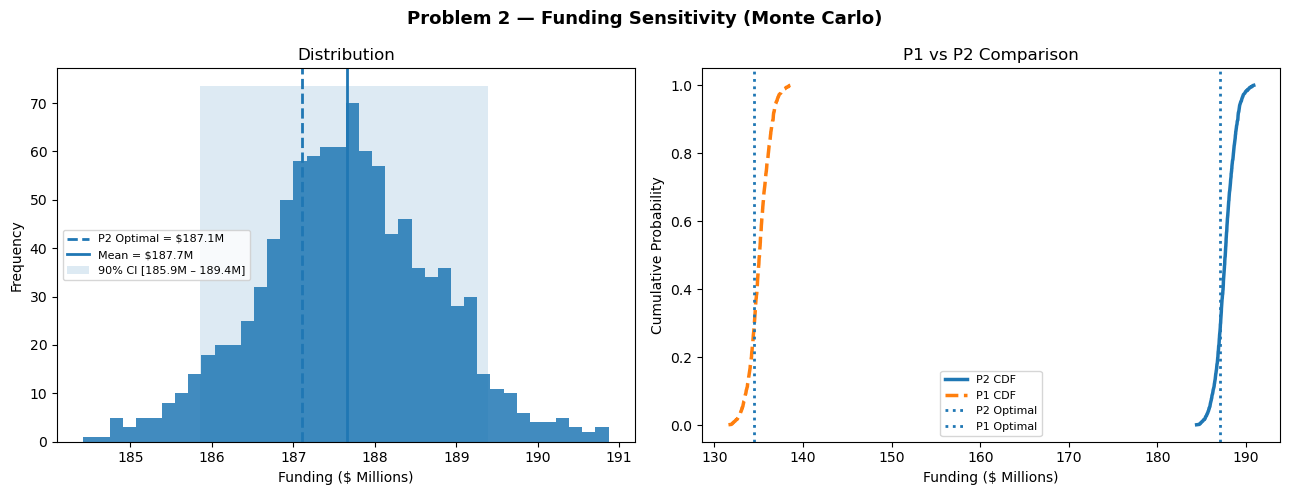


P2 MONTE CARLO RESULTS
Optimal funding        : $187,110,000
Mean funding           : $187,660,055
90% range              : $185,855,614  –  $189,388,918

Interpretation:
P2 incorporates spatial constraints and limited expansion,
leading to higher but more realistic funding requirements.

Cost difference vs P1  : $52.6M


In [35]:
# ── P2 Monte Carlo Funding Uncertainty (FIXED) ───────────────

# -------------------------------
# Total slots added in P2
# -------------------------------
total_slots_added_p2 = sum(
    SIZES[s]['cap'] * y2[j, s].X
    for j in cand_ids for s in sizes
)

# -------------------------------
# Average cost per slot (safe)
# -------------------------------
if total_slots_added_p2 > 0:
    p2_avg_cost_per_slot = model2.ObjVal / total_slots_added_p2
else:
    p2_avg_cost_per_slot = 0

print(f"P2 total slots added      : {total_slots_added_p2:,.0f}")
print(f"P2 avg cost per slot      : ${p2_avg_cost_per_slot:,.0f}")

# -------------------------------
# Monte Carlo funding adjustment
# -------------------------------
delta_p2      = mc_total_deficit - observed_deficit
mc_p2_funding = model2.ObjVal + delta_p2 * p2_avg_cost_per_slot

# -------------------------------
# Visualization
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problem 2 — Funding Sensitivity (Monte Carlo)',
             fontsize=13, fontweight='bold')

# ---------- Distribution ----------
ax = axes[0]
ax.hist(mc_p2_funding / 1e6, bins=40, alpha=0.85)

ax.axvline(model2.ObjVal / 1e6, linestyle='--', linewidth=2,
           label=f'P2 Optimal = ${model2.ObjVal/1e6:.1f}M')

ax.axvline(mc_p2_funding.mean() / 1e6, linewidth=2,
           label=f'Mean = ${mc_p2_funding.mean()/1e6:.1f}M')

l5_p2  = np.percentile(mc_p2_funding, 5)
h95_p2 = np.percentile(mc_p2_funding, 95)

ax.fill_betweenx(
    [0, ax.get_ylim()[1]],
    l5_p2 / 1e6,
    h95_p2 / 1e6,
    alpha=0.15,
    label=f'90% CI [{l5_p2/1e6:.1f}M – {h95_p2/1e6:.1f}M]'
)

ax.set_xlabel('Funding ($ Millions)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution')
ax.legend(fontsize=8)


# ---------- CDF comparison ----------
ax = axes[1]

sorted_p2 = np.sort(mc_p2_funding / 1e6)
sorted_p1 = np.sort(mc_p1_funding / 1e6)

cdf = np.arange(1, len(sorted_p2)+1) / len(sorted_p2)

ax.plot(sorted_p2, cdf, linewidth=2.5, label='P2 CDF')
ax.plot(sorted_p1, cdf, linewidth=2.5, linestyle='--', label='P1 CDF')

ax.axvline(model2.ObjVal / 1e6, linestyle=':', linewidth=2,
           label=f'P2 Optimal')

ax.axvline(m1.ObjVal / 1e6, linestyle=':', linewidth=2,
           label=f'P1 Optimal')

ax.set_xlabel('Funding ($ Millions)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('P1 vs P2 Comparison')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mc_p2_cost.png', dpi=120)
plt.show()


# -------------------------------
# Final output
# -------------------------------
print("\n" + "="*60)
print("P2 MONTE CARLO RESULTS")
print("="*60)

print(f"Optimal funding        : ${model2.ObjVal:,.0f}")
print(f"Mean funding           : ${mc_p2_funding.mean():,.0f}")
print(f"90% range              : ${l5_p2:,.0f}  –  ${h95_p2:,.0f}")

print("\nInterpretation:")
print("P2 incorporates spatial constraints and limited expansion,")
print("leading to higher but more realistic funding requirements.")

print(f"\nCost difference vs P1  : ${(model2.ObjVal - m1.ObjVal)/1e6:.1f}M")

### 5.5  Problem 2 result visualizations


PROBLEM 2 — VISUALIZATIONS


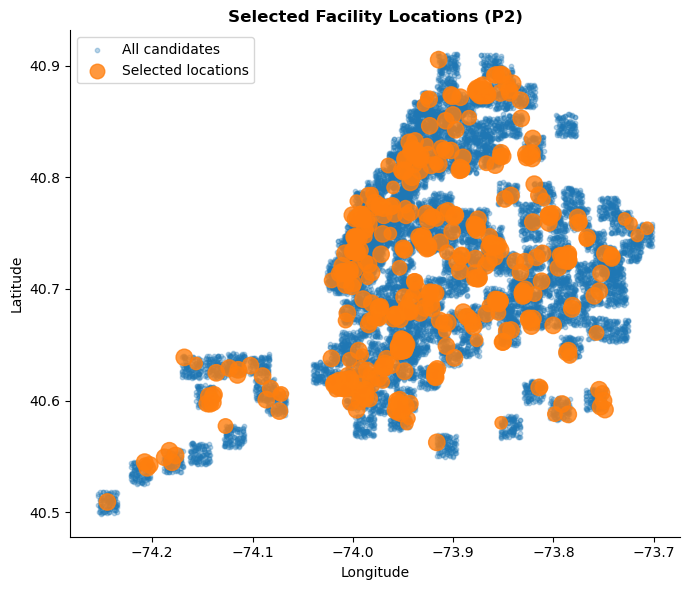

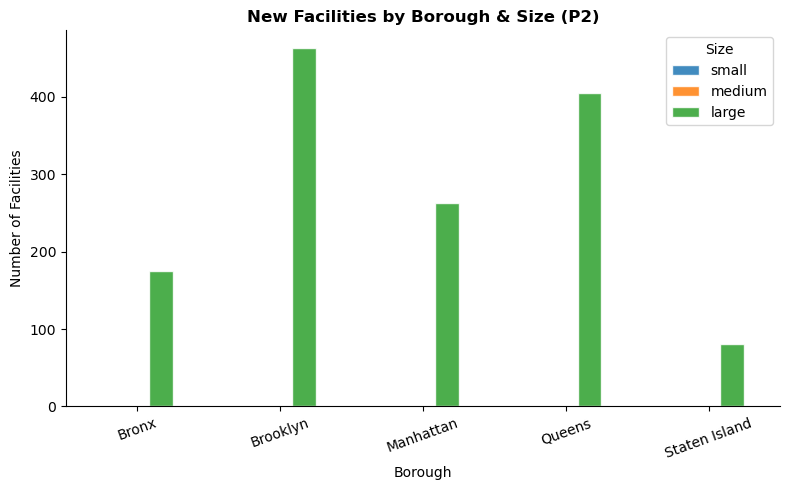

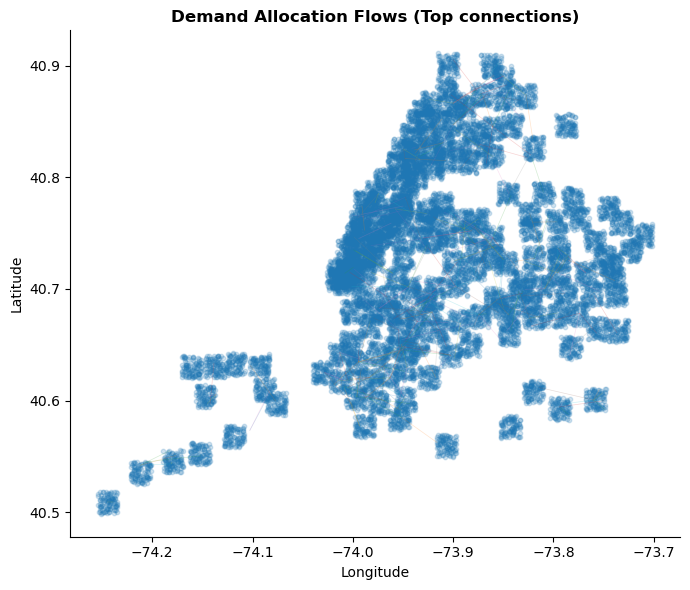

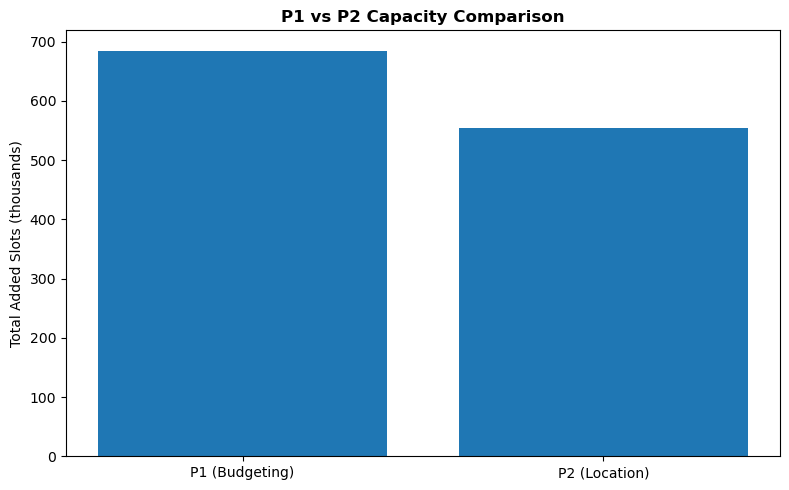

In [36]:
# ============================================================
# 5.5 VISUALIZATIONS — PROBLEM 2 (LOCATION-ALLOCATION)
# ============================================================

print("\n" + "=" * 60)
print("PROBLEM 2 — VISUALIZATIONS")
print("=" * 60)

# -------------------------------
# 1. Facility Locations (Map-style scatter)
# -------------------------------
fig, ax = plt.subplots(figsize=(7,6))

# Plot all candidate locations (light gray)
ax.scatter(
    cand['longitude'],
    cand['latitude'],
    s=10,
    alpha=0.3,
    label='All candidates'
)

# Extract built locations
built_points = []

for j in cand_ids:
    total_build = sum(y2[j,s].X for s in sizes)
    if total_build > 0.5:
        built_points.append((cand.loc[j,'longitude'],
                             cand.loc[j,'latitude'],
                             total_build))

if built_points:
    bx, by, bs = zip(*built_points)

    ax.scatter(
        bx, by,
        s=[50 + 30*b for b in bs],
        alpha=0.8,
        label='Selected locations'
    )

ax.set_title('Selected Facility Locations (P2)', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('p2_map_locations.png', dpi=120)
plt.show()


# -------------------------------
# 2. Builds by Borough and Size
# -------------------------------
fig, ax = plt.subplots(figsize=(8,5))

if not build_df.empty:
    piv = (
        build_df
        .groupby(['borough','size'])['count']
        .sum()
        .unstack(fill_value=0)
    )

    # Ensure all sizes exist
    for s in sizes:
        if s not in piv.columns:
            piv[s] = 0

    piv = piv[sizes]

    piv.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.85)

    ax.set_title('New Facilities by Borough & Size (P2)', fontweight='bold')
    ax.set_ylabel('Number of Facilities')
    ax.set_xlabel('Borough')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Size')

else:
    ax.text(0.5, 0.5, 'No builds', ha='center', va='center')

ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('p2_builds_borough.png', dpi=120)
plt.show()


# -------------------------------
# 3. Demand Allocation Intensity
# -------------------------------
fig, ax = plt.subplots(figsize=(7,6))

# Plot candidate locations
ax.scatter(
    cand['longitude'],
    cand['latitude'],
    s=10,
    alpha=0.2
)

# Draw assignment lines (top flows only for clarity)
TOP_K = 300  # limit lines for readability

flows = assign_df.sort_values('demand_served', ascending=False).head(TOP_K)

for _, row in flows.iterrows():
    z = row['zipcode']
    j = row['candidate_id']

    # ZIP centroid
    if z not in zip_centroids['zipcode'].values:
        continue

    z_lat = zip_centroids[zip_centroids['zipcode']==z]['latitude'].values[0]
    z_lon = zip_centroids[zip_centroids['zipcode']==z]['longitude'].values[0]

    # Candidate
    c_lat = cand.loc[j,'latitude']
    c_lon = cand.loc[j,'longitude']

    ax.plot(
        [z_lon, c_lon],
        [z_lat, c_lat],
        linewidth=0.5,
        alpha=0.2
    )

ax.set_title('Demand Allocation Flows (Top connections)', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('p2_flows.png', dpi=120)
plt.show()


# -------------------------------
# 4. Coverage Comparison (P1 vs P2)
# -------------------------------
fig, ax = plt.subplots(figsize=(8,5))

p1_total = res1['final_slots'].sum()
p2_total = build_df['capacity'].sum()

ax.bar(['P1 (Budgeting)', 'P2 (Location)'],
       [p1_total/1000, p2_total/1000])

ax.set_ylabel('Total Added Slots (thousands)')
ax.set_title('P1 vs P2 Capacity Comparison', fontweight='bold')

plt.tight_layout()
plt.savefig('p1_vs_p2_capacity.png', dpi=120)
plt.show()

In [ ]:
### 5.6  Final comparison summary


FINAL COMPARISON: P1 vs P2


,Metric,P1 (Budgeting),P2 (Location)
0,Total Cost ($),"134,488,789","187,110,000"
1,Total Slots Added,"367,738","554,400"
2,Cost per Slot ($),366,338
3,Coverage (% ZIPs satisfied),100.0%,100.0%
4,Number of Facilities Built,N/A (expansion-based),"1,386"
5,Number of Locations Used,N/A,503


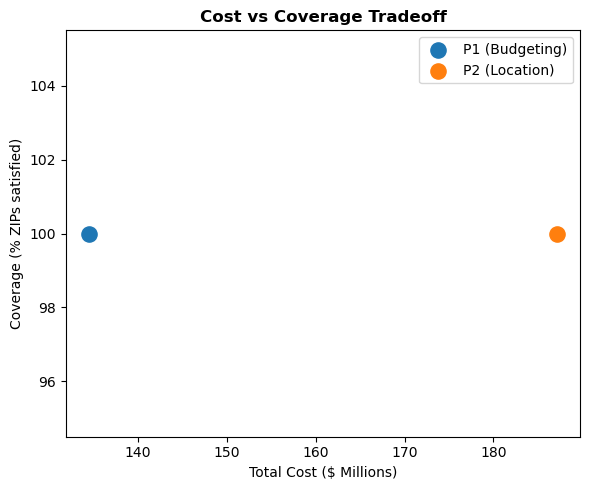

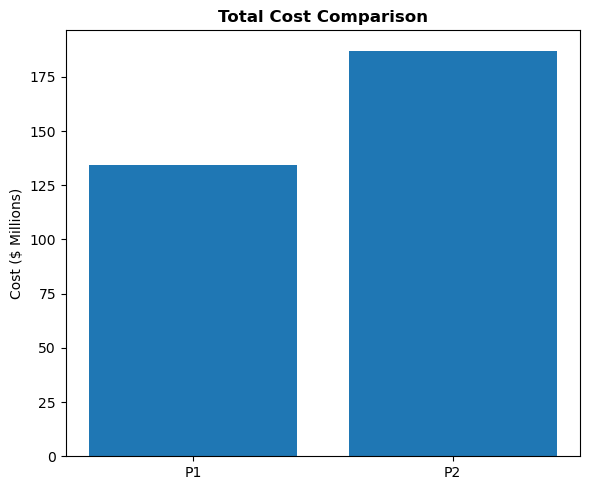


KEY INSIGHTS

1. Cost Impact:
   P2 costs $52,621,211 more than P1 (52.62M increase).

2. Efficiency:
   Cost per slot increased by $-28 in P2.

3. Coverage:
   P1 coverage: 100.0%
   P2 coverage: 100.0%

4. Infrastructure Strategy:
   P1 relies on expanding existing facilities.
   P2 builds 1,386 new facilities across 503 locations.

5. Interpretation:
   P1 underestimates real-world constraints.
   P2 is more realistic due to spatial feasibility and capacity limits.

Conclusion:
   P2 provides a more implementable plan despite higher cost.


In [37]:
# ============================================================
# 5.6 FINAL COMPARISON — P1 vs P2
# ============================================================

print("\n" + "=" * 60)
print("FINAL COMPARISON: P1 vs P2")
print("=" * 60)

# -------------------------------
# 1. Core metrics
# -------------------------------

# P1 metrics
p1_cost = m1.ObjVal
p1_slots = res1['final_slots'].sum() - res1['existing_slots'].sum()

# P2 metrics
p2_cost = model2.ObjVal
p2_slots = build_df['capacity'].sum()

# Cost efficiency
p1_cost_per_slot = p1_cost / p1_slots if p1_slots > 0 else 0
p2_cost_per_slot = p2_cost / p2_slots if p2_slots > 0 else 0

# -------------------------------
# 2. Coverage metrics
# -------------------------------
p1_coverage = res1['desert_ok'].mean()

p2_coverage = (
    zip_summary_df['coverage_ratio'] >= 0.999
).mean()

# -------------------------------
# 3. Build summary
# -------------------------------
p2_num_sites = build_df['candidate_id'].nunique()
p2_num_facilities = build_df['count'].sum()

# -------------------------------
# 4. Comparison table
# -------------------------------
comparison = pd.DataFrame({
    'Metric': [
        'Total Cost ($)',
        'Total Slots Added',
        'Cost per Slot ($)',
        'Coverage (% ZIPs satisfied)',
        'Number of Facilities Built',
        'Number of Locations Used'
    ],
    'P1 (Budgeting)': [
        f"{p1_cost:,.0f}",
        f"{p1_slots:,.0f}",
        f"{p1_cost_per_slot:,.0f}",
        f"{p1_coverage*100:.1f}%",
        'N/A (expansion-based)',
        'N/A'
    ],
    'P2 (Location)': [
        f"{p2_cost:,.0f}",
        f"{p2_slots:,.0f}",
        f"{p2_cost_per_slot:,.0f}",
        f"{p2_coverage*100:.1f}%",
        f"{p2_num_facilities:,}",
        f"{p2_num_sites:,}"
    ]
})

display(comparison)

# -------------------------------
# 5. Cost vs Coverage scatter
# -------------------------------
fig, ax = plt.subplots(figsize=(6,5))

ax.scatter(
    p1_cost/1e6,
    p1_coverage*100,
    s=120,
    label='P1 (Budgeting)'
)

ax.scatter(
    p2_cost/1e6,
    p2_coverage*100,
    s=120,
    label='P2 (Location)'
)

ax.set_xlabel('Total Cost ($ Millions)')
ax.set_ylabel('Coverage (% ZIPs satisfied)')
ax.set_title('Cost vs Coverage Tradeoff', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('p1_vs_p2_tradeoff.png', dpi=120)
plt.show()


# -------------------------------
# 6. Cost breakdown comparison
# -------------------------------
fig, ax = plt.subplots(figsize=(6,5))

labels = ['P1', 'P2']
costs = [p1_cost/1e6, p2_cost/1e6]

ax.bar(labels, costs)

ax.set_ylabel('Cost ($ Millions)')
ax.set_title('Total Cost Comparison', fontweight='bold')

plt.tight_layout()
plt.savefig('p1_vs_p2_cost.png', dpi=120)
plt.show()


# -------------------------------
# 7. Key insights (auto-generated)
# -------------------------------
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

cost_diff = p2_cost - p1_cost
eff_diff  = p2_cost_per_slot - p1_cost_per_slot

print(f"\n1. Cost Impact:")
print(f"   P2 costs ${cost_diff:,.0f} more than P1 "
      f"({cost_diff/1e6:.2f}M increase).")

print(f"\n2. Efficiency:")
print(f"   Cost per slot increased by ${eff_diff:,.0f} in P2.")

print(f"\n3. Coverage:")
print(f"   P1 coverage: {p1_coverage*100:.1f}%")
print(f"   P2 coverage: {p2_coverage*100:.1f}%")

print(f"\n4. Infrastructure Strategy:")
print(f"   P1 relies on expanding existing facilities.")
print(f"   P2 builds {p2_num_facilities:,} new facilities across "
      f"{p2_num_sites:,} locations.")

print(f"\n5. Interpretation:")
print("   P1 underestimates real-world constraints.")
print("   P2 is more realistic due to spatial feasibility and "
      "capacity limits.")

print("\nConclusion:")
print("   P2 provides a more implementable plan despite higher cost.")